In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [73]:
df = pd.read_csv("heart.csv")

In [74]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [75]:
#EDA

In [76]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [77]:
df.shape

(918, 12)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [79]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


<Axes: xlabel='HeartDisease'>

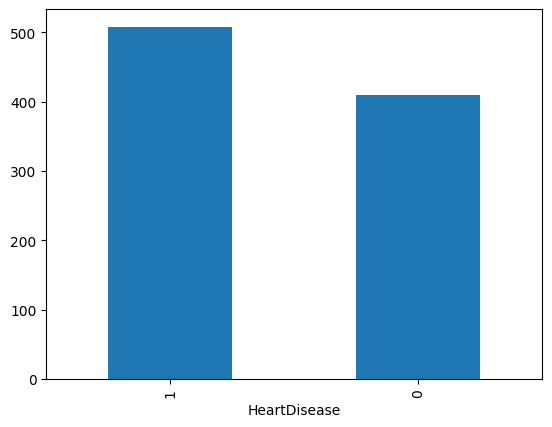

In [82]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

In [83]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


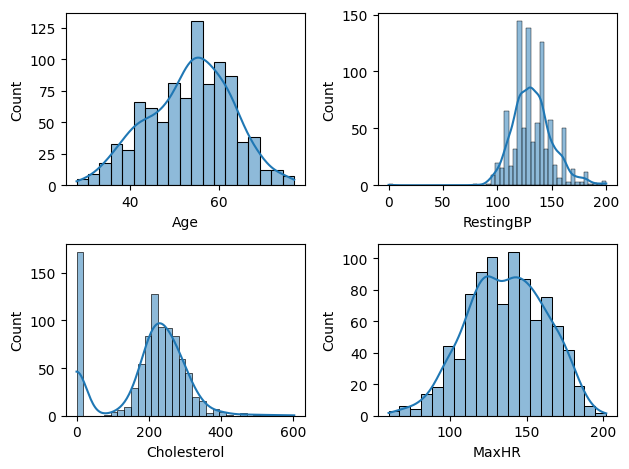

In [84]:
def plotting(var ,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var] , kde = True)
plotting('Age' , 1)
plotting('RestingBP' , 2)
plotting('Cholesterol' , 3)
plotting('MaxHR' , 4)

plt.tight_layout()      #fon not be overlap of grpahs in a sheet

In [85]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [86]:
# data invalid shown  -> 1. 0 in restingBP , 2. 0 in cholesterol

In [87]:
ch_mean = df.loc[df['Cholesterol'] != 0 , 'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [88]:
df['Cholesterol'] = df['Cholesterol'].replace(0 , ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [89]:
Resting_bp_mean = df.loc[df['RestingBP'] != 0 , 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0 , ch_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [90]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


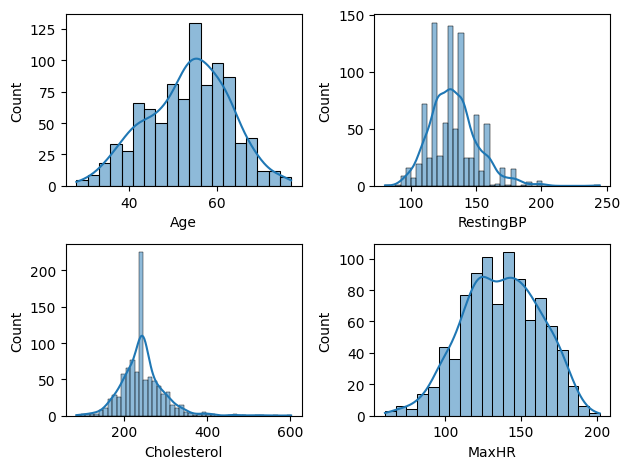

In [91]:
def plotting(var ,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var] , kde = True)
plotting('Age' , 1)
plotting('RestingBP' , 2)
plotting('Cholesterol' , 3)
plotting('MaxHR' , 4)

plt.tight_layout()      #fon not be overlap of grpahs in a sheet

In [92]:
#now categorial

<Axes: xlabel='Sex', ylabel='count'>

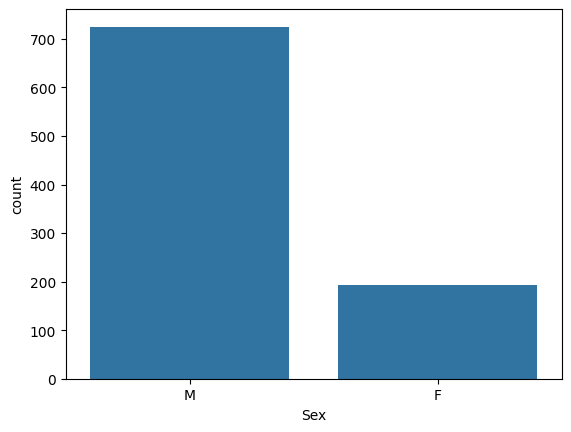

In [93]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

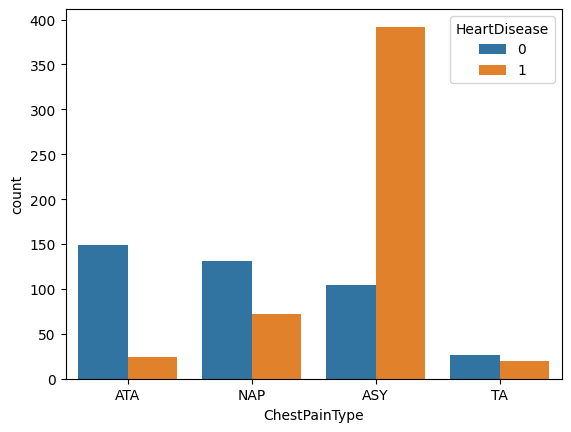

In [94]:
sns.countplot( x= df['ChestPainType'] , hue = df['HeartDisease'])

<Axes: xlabel='Sex', ylabel='count'>

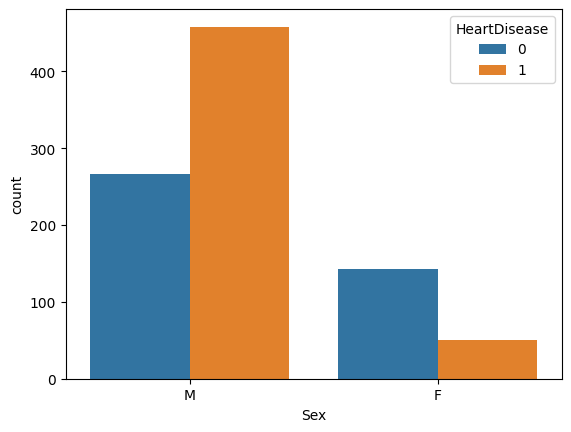

In [95]:
sns.countplot(x = df['Sex'] , hue= df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

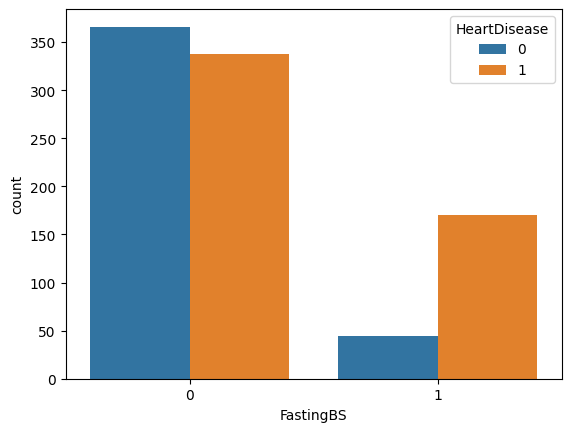

In [96]:
sns.countplot(x = df['FastingBS'] , hue = df['HeartDisease'])

<Axes: xlabel='Cholesterol'>

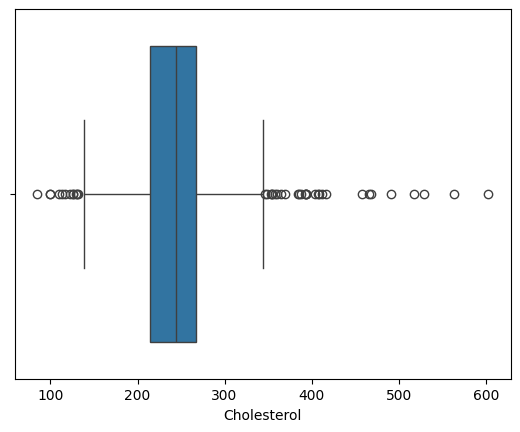

In [97]:
sns.boxplot( x = df['Cholesterol'] , data = df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

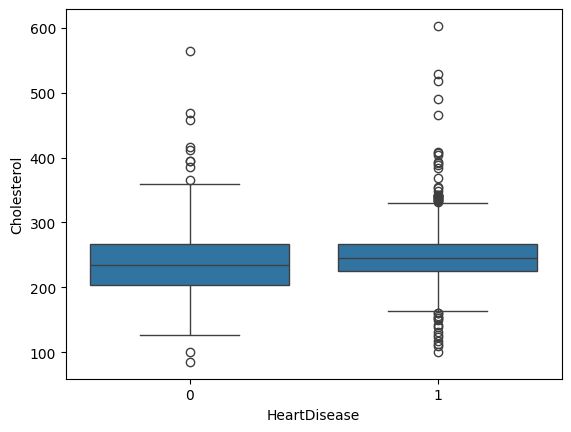

In [98]:
sns.boxplot( x = df['HeartDisease']  ,y =  df['Cholesterol'] , data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

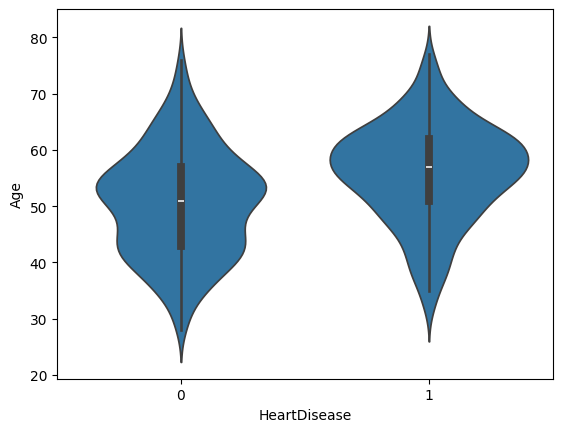

In [99]:
sns.violinplot(x = df['HeartDisease'] , y = df['Age'] , data = df)

<Axes: >

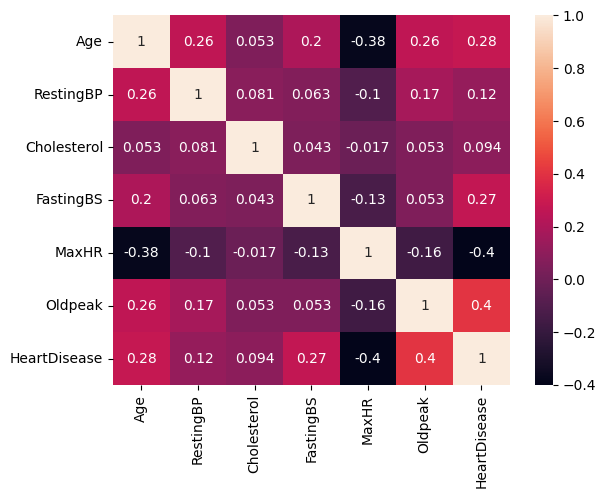

In [100]:
sns.heatmap(df.corr(numeric_only = True) , annot = True)

# Data preprocessing and Cleaning

In [101]:
df_encode = pd.get_dummies(df  , drop_first = True)

In [102]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [103]:
df_encode = df_encode.astype(int)

In [104]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [105]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age'  , 'RestingBP' , 'Cholesterol' , 'MaxHR'  , 'Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.489614,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.290847,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.944720,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [106]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.489614,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.290847,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.944720,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.234855,0.365619,0,-0.188999,0.282891,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.617784,-0.966725,1,0.164684,2.303858,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.145068,-2.130180,0,-0.857069,0.282891,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.145068,-0.159813,0,1.461525,-0.727592,1,0,1,0,0,0,0,0,1,0


In [107]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report ,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


In [109]:
x = df_encode.drop('HeartDisease' , axis = 1)
y = df_encode['HeartDisease']

In [110]:
x

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.834754,0,1.382928,-0.727592,1,1,0,0,1,0,0,0,1
1,-0.478484,1.489614,-1.210675,0,0.754157,0.282891,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.722161,0,-1.525138,-0.727592,1,1,0,0,0,1,0,0,1
3,-0.584556,0.290847,-0.572651,0,-1.132156,0.282891,0,0,0,0,1,0,1,1,0
4,0.051881,0.944720,-0.929194,0,-0.581981,-0.727592,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.234855,0.365619,0,-0.188999,0.282891,1,0,0,1,1,0,0,1,0
914,1.536902,0.617784,-0.966725,1,0.164684,2.303858,1,0,0,0,1,0,0,1,0
915,0.370100,-0.145068,-2.130180,0,-0.857069,0.282891,1,0,0,0,1,0,1,1,0
916,0.370100,-0.145068,-0.159813,0,1.461525,-0.727592,0,1,0,0,0,0,0,1,0


In [111]:
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [112]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled   = scaler.fit_transform(x_test)

In [113]:
models = {
    "LogisticRegression" : LogisticRegression(),
    "Naive Byeas" : GaussianNB(),
    "Decision Tree" : DecisionTreeClassifier(),
    "SVM" : SVC(),
    "KNN" : KNeighborsClassifier(),
}

In [114]:
result = []

In [115]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

for name,model in models.items():
  model.fit(x_train_scaled , y_train)
  y_pred = model.predict(x_test_scaled)
  accuracy = accuracy_score(y_test , y_pred)
  f1 = f1_score(y_test , y_pred)
  result.append({
      'model_name' : name,
      'accuracy' : round(accuracy, 2),
      'confusion_matrix' : confusion_matrix(y_test , y_pred),
      "f1 score" : round(f1 , 4)
  }
  )

In [116]:
result

[{'model_name': 'LogisticRegression',
  'accuracy': 0.87,
  'confusion_matrix': array([[67, 10],
         [14, 93]]),
  'f1 score': 0.8857},
 {'model_name': 'Naive Byeas',
  'accuracy': 0.85,
  'confusion_matrix': array([[68,  9],
         [18, 89]]),
  'f1 score': 0.8683},
 {'model_name': 'Decision Tree',
  'accuracy': 0.77,
  'confusion_matrix': array([[61, 16],
         [27, 80]]),
  'f1 score': 0.7882},
 {'model_name': 'SVM',
  'accuracy': 0.85,
  'confusion_matrix': array([[64, 13],
         [15, 92]]),
  'f1 score': 0.8679},
 {'model_name': 'KNN',
  'accuracy': 0.87,
  'confusion_matrix': array([[67, 10],
         [14, 93]]),
  'f1 score': 0.8857}]

In [118]:
import joblib
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']